# Cell 1 — Check GPU

In [1]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU. In Colab: Runtime -> Change runtime type -> GPU")

CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


# Cell 2 — Clone the correct branch

In [2]:
!rm -rf Image-Style-Transfer

!git clone \
  --branch version1 \
  --single-branch \
  https://github.com/yani0514/Image-Style-Transfer.git

%cd Image-Style-Transfer

'rm' is not recognized as an internal or external command,
operable program or batch file.


d:\Yanislav\University of Luxembourg\Semester 4 - Erasmus TU Wien\Introduction to Deep Learning\Deep_Learning_project\Image-Style-Transfer\notebooks\Image-Style-Transfer


fatal: destination path 'Image-Style-Transfer' already exists and is not an empty directory.


# Cell 3 — Confirm you are on version1

In [3]:
!git branch
!git log --oneline -5
!ls

* version1
f44c0d0 Add ipynb 3-way model comparison
2033b15 Tweaks 2
05fbe65 Tweaks 1
bda4c20 Tweaks 1
ba13be1 Initial commit of version1


'ls' is not recognized as an internal or external command,
operable program or batch file.


# Cell 4 — Install dependencies

In [4]:
!pip install -r requirements.txt


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Cell 5 — Check project scripts

In [5]:
!ls scripts
!python scripts/train_transformer.py --help

'ls' is not recognized as an internal or external command,
operable program or batch file.


usage: train_transformer.py train-transformer [-h] --content-dir CONTENT_DIR
                                              --style-dir STYLE_DIR
                                              --output-checkpoint OUTPUT_CHECKPOINT
                                              [--image-size IMAGE_SIZE]
                                              [--batch-size BATCH_SIZE]
                                              [--steps STEPS]
                                              [--learning-rate LEARNING_RATE]
                                              [--content-weight CONTENT_WEIGHT]
                                              [--style-weight STYLE_WEIGHT]
                                              [--tv-weight TV_WEIGHT]
                                              [--num-workers NUM_WORKERS]
                                              [--save-every SAVE_EVERY]
                                              [--log-every LOG_EVERY]
                                             

## Cell 6 — Check your current data

In [6]:
!find data/content -maxdepth 1 -type f
!find data/styles -maxdepth 1 -type f

FIND: Parameter format not correct
FIND: Parameter format not correct


# Cell 7 — Make output folders

In [7]:
!mkdir -p checkpoints outputs/transformer outputs/transformer_eval

The syntax of the command is incorrect.


# Cell 8 — Short debug training first

In [8]:
!python scripts/train_transformer.py \
  --content-dir data/content \
  --style-dir data/styles \
  --output-checkpoint checkpoints/transformer_debug.pth \
  --image-size 128 \
  --batch-size 1 \
  --steps 50 \
  --save-every 25 \
  --log-every 5 \
  --hidden-dim 256 \
  --num-heads 8 \
  --num-layers 4 \
  --alpha 0.8 \
  --device cuda \
  --pretrained yes

Saved checkpoints/transformer_debug.pth
Saved checkpoints\transformer_debug.json


d:\Yanislav\University of Luxembourg\Semester 4 - Erasmus TU Wien\Introduction to Deep Learning\Deep_Learning_project\Image-Style-Transfer\venv\Lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(

Train transformer:   0%|          | 0/50 [00:00<?, ?it/s]D:\Yanislav\University of Luxembourg\Semester 4 - Erasmus TU Wien\Introduction to Deep Learning\Deep_Learning_project\Image-Style-Transfer\notebooks\Image-Style-Transfer\src\style_transfer\io.py:26: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  data = torch.ByteTensor(torch.ByteStorage.from_buffer(image.tobytes()))

Train transformer: 100%|██████████| 50/50 [00:

# Cell 9 — Test the debug checkpoint on one image

In [9]:
!python scripts/run_transformer.py \
  --content data/content/family.jpg \
  --style data/styles/starry_night.jpg \
  --output outputs/transformer/debug_family_starry.png \
  --checkpoint checkpoints/transformer_debug.pth \
  --image-size 512 \
  --alpha 0.8 \
  --device cuda

Saved outputs\transformer\debug_family_starry.png


D:\Yanislav\University of Luxembourg\Semester 4 - Erasmus TU Wien\Introduction to Deep Learning\Deep_Learning_project\Image-Style-Transfer\notebooks\Image-Style-Transfer\src\style_transfer\io.py:26: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  data = torch.ByteTensor(torch.ByteStorage.from_buffer(image.tobytes()))
d:\Yanislav\University of Luxembourg\Semester 4 - Erasmus TU Wien\Introduction to Deep Learning\Deep_Learning_project\Image-Style-Transfer\venv\Lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


# Cell 10 — Show the debug result

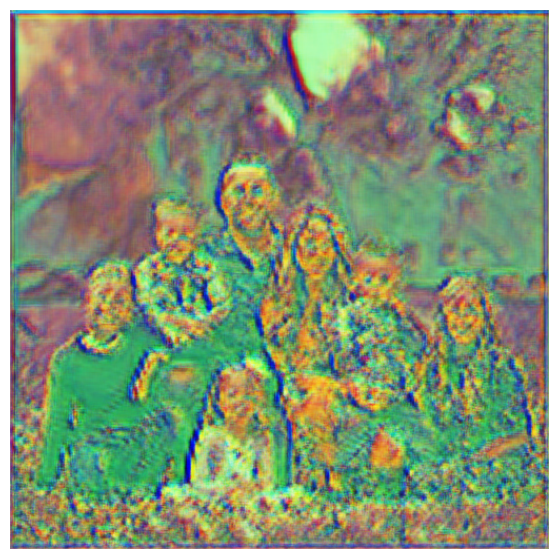

In [10]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("outputs/transformer/debug_family_starry.png")

plt.figure(figsize=(7, 7))
plt.imshow(img)
plt.axis("off")
plt.show()

# Cell 11 — Real training, 20k steps version

In [11]:
!python scripts/train_transformer.py \
  --content-dir data/content \
  --style-dir data/styles \
  --output-checkpoint checkpoints/transformer_stylizer.pth \
  --image-size 256 \
  --batch-size 2 \
  --steps 20000 \
  --save-every 1000 \
  --log-every 50 \
  --hidden-dim 256 \
  --num-heads 8 \
  --num-layers 4 \
  --alpha 0.8 \
  --device cuda \
  --pretrained yes

^C


# Cell 12 — DONT RUN THIS - Stronger training version

In [ ]:
# !python scripts/train_transformer.py \
#   --content-dir data/content \
#   --style-dir data/styles \
#   --output-checkpoint checkpoints/transformer_stylizer.pth \
#   --image-size 256 \
#   --batch-size 4 \
#   --steps 20000 \
#   --save-every 1000 \
#   --log-every 50 \
#   --hidden-dim 256 \
#   --num-heads 8 \
#   --num-layers 4 \
#   --alpha 0.8 \
#   --device cuda \
#   --pretrained yes

# Cell 13 — Run Transformer on one pair

In [12]:
!python scripts/run_transformer.py \
  --content data/content/family.jpg \
  --style data/styles/starry_night.jpg \
  --output outputs/transformer/family__starry_night__transformer.png \
  --checkpoint checkpoints/transformer_stylizer.pth \
  --image-size 512 \
  --alpha 0.8 \
  --device cuda

Saved outputs\transformer\family__starry_night__transformer.png


D:\Yanislav\University of Luxembourg\Semester 4 - Erasmus TU Wien\Introduction to Deep Learning\Deep_Learning_project\Image-Style-Transfer\notebooks\Image-Style-Transfer\src\style_transfer\io.py:26: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  data = torch.ByteTensor(torch.ByteStorage.from_buffer(image.tobytes()))
d:\Yanislav\University of Luxembourg\Semester 4 - Erasmus TU Wien\Introduction to Deep Learning\Deep_Learning_project\Image-Style-Transfer\venv\Lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


# Cell 14 — Display result

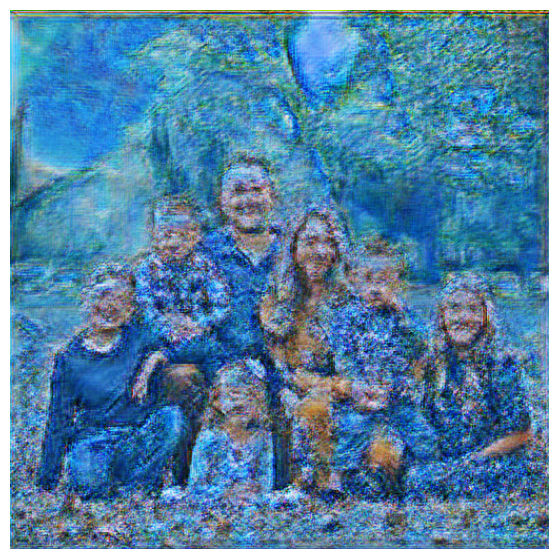

In [13]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("outputs/transformer/family__starry_night__transformer.png")

plt.figure(figsize=(7, 7))
plt.imshow(img)
plt.axis("off")
plt.show()

# Cell 15 — Run Transformer over all content/style pairs

In [14]:
!python scripts/run_batch.py \
  --method transformer \
  --content-dir data/content \
  --style-dir data/styles \
  --output-dir outputs/transformer \
  --checkpoint checkpoints/transformer_stylizer.pth \
  --image-size 512 \
  --alpha 0.8 \
  --device cuda

Saved outputs\transformer\manifest.json


d:\Yanislav\University of Luxembourg\Semester 4 - Erasmus TU Wien\Introduction to Deep Learning\Deep_Learning_project\Image-Style-Transfer\venv\Lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
D:\Yanislav\University of Luxembourg\Semester 4 - Erasmus TU Wien\Introduction to Deep Learning\Deep_Learning_project\Image-Style-Transfer\notebooks\Image-Style-Transfer\src\style_transfer\io.py:26: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  data = torch.ByteTensor(torch.ByteStorage.from_buffer(image.tobytes()))


# Cell 16 — Make a gallery

In [15]:
!python scripts/make_gallery.py \
  --content-dir data/content \
  --style-dir data/styles \
  --output-dir outputs/transformer \
  --gallery-path outputs/transformer_gallery.jpg

Saved outputs\transformer_gallery.jpg


# Cell 17 — Show gallery

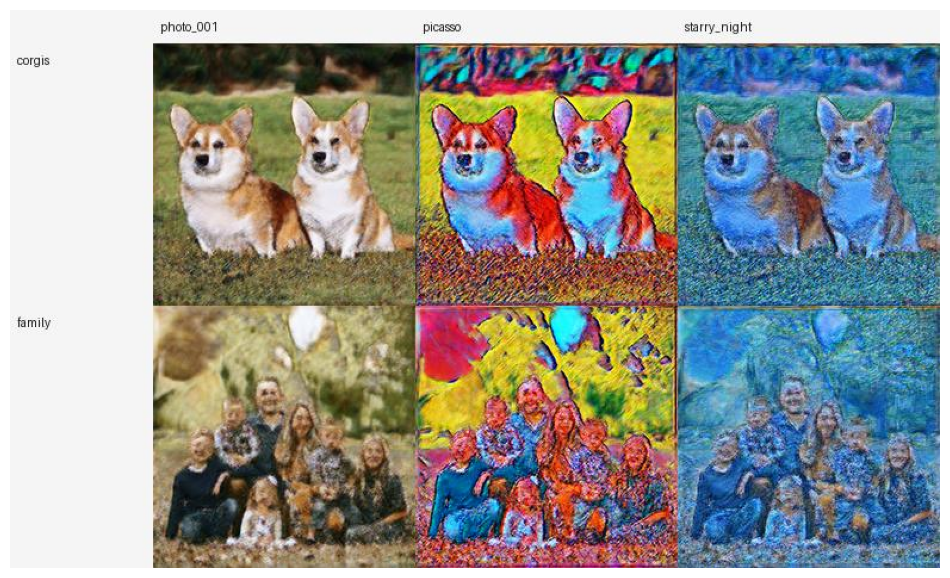

In [16]:
from PIL import Image
import matplotlib.pyplot as plt

gallery = Image.open("outputs/transformer_gallery.jpg")

plt.figure(figsize=(12, 12))
plt.imshow(gallery)
plt.axis("off")
plt.show()

# Cell 18 — Evaluate Transformer outputs

In [17]:
# Patching
from pathlib import Path

path = Path("src/style_transfer/cli.py")
text = path.read_text()

old = "summary = ok_rows.describe(numeric_only=True)"
new = "summary = ok_rows.select_dtypes(include='number').describe()"

if old in text:
    path.write_text(text.replace(old, new))
    print("Patched evaluate summary line successfully.")
else:
    print("Line not found. Maybe it was already patched.")

!python scripts/evaluate.py \
  --content-dir data/content \
  --style-dir data/styles \
  --output-dir outputs/transformer \
  --metrics-csv outputs/transformer_metrics.csv \
  --image-size 512 \
  --device cuda \
  --pretrained yes

Patched evaluate summary line successfully.
Saved outputs\transformer_metrics.csv
Saved outputs\transformer_metrics.summary.csv


D:\Yanislav\University of Luxembourg\Semester 4 - Erasmus TU Wien\Introduction to Deep Learning\Deep_Learning_project\Image-Style-Transfer\notebooks\Image-Style-Transfer\src\style_transfer\io.py:26: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  data = torch.ByteTensor(torch.ByteStorage.from_buffer(image.tobytes()))


# Cell 19 — Read metrics

In [18]:
import pandas as pd

metrics = pd.read_csv("outputs/transformer_metrics.csv")
metrics.head()

,content,style,output,status,content_vgg_mse,style_gram_mse,style_stats_mse
0,corgis.png,photo_001.jpg,outputs\transformer\corgis__photo_001__transfo...,ok,5.196022,0.000010,0.510492
1,corgis.png,picasso.png,outputs\transformer\corgis__picasso__transform...,ok,11.357889,0.000247,2.145793
2,corgis.png,starry_night.jpg,outputs\transformer\corgis__starry_night__tran...,ok,7.600040,0.000102,1.281226
3,family.jpg,photo_001.jpg,outputs\transformer\family__photo_001__transfo...,ok,13.897175,0.000012,0.638379
4,family.jpg,picasso.png,outputs\transformer\family__picasso__transform...,ok,19.288097,0.000268,2.421126


# Cell 20 — Download checkpoint and outputs

In [19]:
from google.colab import files

files.download("checkpoints/transformer_stylizer.pth")
files.download("outputs/transformer_metrics.csv")
files.download("outputs/transformer_gallery.jpg")

ModuleNotFoundError: No module named 'google'

# NST model


# Cell 1 — Check existing NST outputs

In [ ]:
!ls outputs
!find outputs/nst -maxdepth 1 -type f 2>/dev/null | head -20

'ls' is not recognized as an internal or external command,
operable program or batch file.
The system cannot find the path specified.


# RUN ONLY IF NO NST outputs Cell 2 — Regenerate NST outputs only if needed

In [ ]:
# !mkdir -p outputs/nst

# !python scripts/run_batch.py \
#   --method nst \
#   --content-dir data/content \
#   --style-dir data/styles \
#   --output-dir outputs/nst \
#   --image-size 512 \
#   --steps 300 \
#   --device cuda \
#   --pretrained yes

# Cell 3 — Make the NST gallery

In [21]:
!python scripts/make_gallery.py \
  --content-dir data/content \
  --style-dir data/styles \
  --output-dir outputs/nst \
  --gallery-path outputs/nst_gallery.jpg

Saved outputs\nst_gallery.jpg


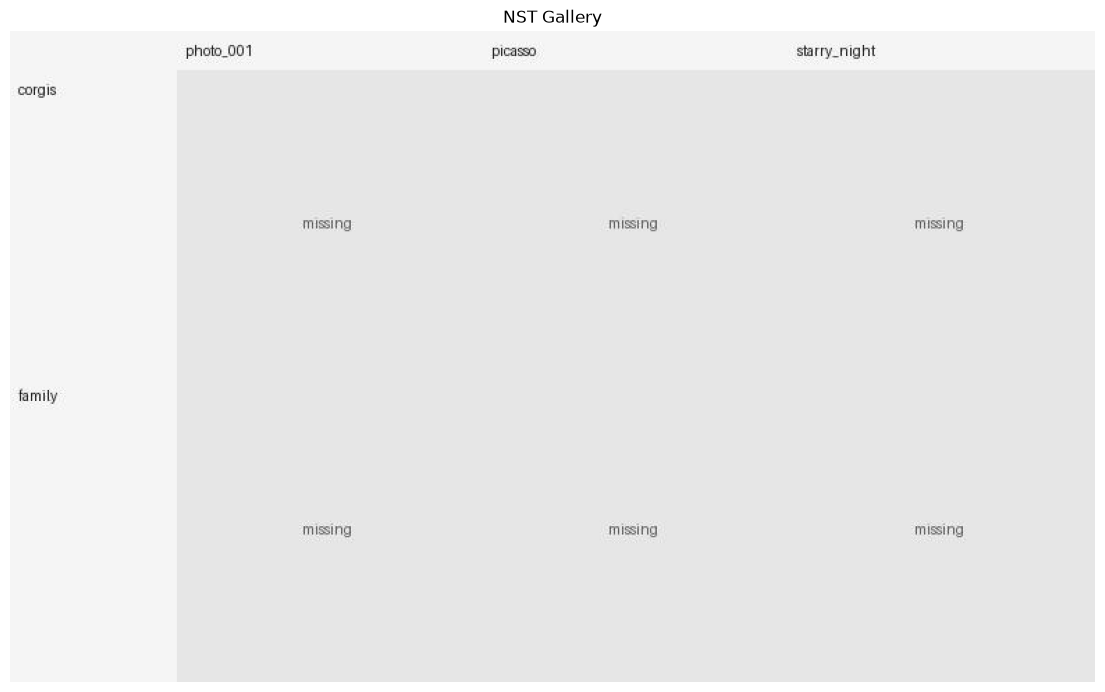

In [22]:
from PIL import Image
import matplotlib.pyplot as plt

gallery = Image.open("outputs/nst_gallery.jpg")

plt.figure(figsize=(14, 14))
plt.imshow(gallery)
plt.axis("off")
plt.title("NST Gallery")
plt.show()

# Cell 5 — Make Transformer gallery again too

In [ ]:
!python scripts/make_gallery.py \
  --content-dir data/content \
  --style-dir data/styles \
  --output-dir outputs/transformer \
  --gallery-path outputs/transformer_gallery.jpg

# Cell 6 — Display NST vs Transformer galleries

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

gallery_paths = {
    "NST": Path("outputs/nst_gallery.jpg"),
    "Transformer": Path("outputs/transformer_gallery.jpg"),
}

existing = {name: path for name, path in gallery_paths.items() if path.exists()}

for name, path in existing.items():
    img = Image.open(path)
    plt.figure(figsize=(14, 14))
    plt.imshow(img)
    plt.axis("off")
    plt.title(name)
    plt.show()

# Optional - Include AdaIN in the comparison too

# Cell 1 — Check that the AdaIN checkpoint exists

In [ ]:
!ls checkpoints
!ls checkpoints/adain_decoder.pth
!ls checkpoints/adain_decoder.json

# Cell 2 — Generate AdaIN outputs for all content-style pairs

In [ ]:
!mkdir -p outputs/adain

!python scripts/run_batch.py \
  --method adain \
  --content-dir data/content \
  --style-dir data/styles \
  --output-dir outputs/adain \
  --decoder-checkpoint checkpoints/adain_decoder.pth \
  --mode decoder \
  --alpha 0.8 \
  --image-size 512 \
  --device cuda \
  --pretrained yes

# Cell 3 — Check that AdaIN outputs were created

In [ ]:
!find outputs/adain -maxdepth 1 -type f | head -20

# Cell 4 — Build the AdaIN gallery

In [ ]:
!python scripts/make_gallery.py \
  --content-dir data/content \
  --style-dir data/styles \
  --output-dir outputs/adain \
  --gallery-path outputs/adain_gallery.jpg

# Cell 5 — Display the AdaIN gallery

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("outputs/adain_gallery.jpg")

plt.figure(figsize=(14, 14))
plt.imshow(img)
plt.axis("off")
plt.title("AdaIN Gallery")
plt.show()

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

gallery_paths = {
    "NST": Path("outputs/nst_gallery.jpg"),
    "AdaIN": Path("outputs/adain_gallery.jpg"),
    "Transformer": Path("outputs/transformer_gallery.jpg"),
}

for name, path in gallery_paths.items():
    if not path.exists():
        print(f"Skipping {name}: {path} not found")
        continue

    img = Image.open(path)
    plt.figure(figsize=(14, 14))
    plt.imshow(img)
    plt.axis("off")
    plt.title(name)
    plt.show()

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

paths = {
    "NST": "outputs/nst/family__starry_night.png",
    "AdaIN": "outputs/adain/family__starry_night.png",
    "Transformer": "outputs/transformer/family__starry_night.png",
}

for name, path in paths.items():
    try:
        img = Image.open(path)
        plt.figure(figsize=(6, 6))
        plt.imshow(img)
        plt.axis("off")
        plt.title(name)
        plt.show()
    except FileNotFoundError:
        print(f"{name} image not found at {path}")